# E60 · How hard does a cell pull? Traction force microscopy as a Bayesian inverse problem

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Part one: **simulated** - a 40 µm cell on an 8 kPa gel pulling through 16 focal adhesions of known force (6 strong ones at the tips, 10 weak ones of 0.5-1 nN along the sides), with bead displacements on a 1 µm grid and 10 nm tracking noise. The ground truth makes every regularisation choice checkable. Part two: **real** - the displacement field under a colony of 7 cells on a 49 kPa gel, measured by PIV, from the example data of the pyTFM software (Bauer et al. 2021, *PLoS Comput. Biol.*), with pyTFM's own tractions and force summaries for comparison |
| **You will learn** | The physics of **traction force microscopy** (TFM): a soft gel as a force sensor, the Boussinesq Green's function and why it is diagonal in Fourier space (Fourier-transform traction cytometry, FTTC) · a longitudinal / transverse split that turns the 2-D vector problem into independent scalar problems · why the inverse problem is **ill-posed**, and **Tikhonov regularisation** as exactly a Gaussian prior · choosing λ: the **L-curve**, the discrepancy principle, and the **marginal likelihood** (closed form, one line of NumPy) - checked against the truth · full Bayes over the hyperparameters in PyMC with the traction field integrated out, then exact joint posterior draws of the field · **GP smoothness priors** as spectra in Fourier space, and reading the data's power spectrum as a predictive check · credible intervals for strain energy, contractile moment and total force, and which of them a prior can bias · **Young's modulus** uncertainty: forces scale with E, and a 15% AFM error swamps everything else · priors that know about cells: the **cell footprint** (constrained TFM) and a **regularised horseshoe** for sparse focal adhesions (NUTS on 1,300 traction components) |

## Cells feel by pulling

Cells in the body are not just chemical machines: they sense how stiff their surroundings are, and
respond. A stem cell on a soft gel becomes more nerve-like, on a stiff one more bone-like (Engler et
al. 2006, *Cell*); tumour cells pull harder than their healthy neighbours; wound healing and
embryonic development are, in part, a matter of cells pulling tissue into shape. The machinery is
the **cytoskeleton** - actin fibres and myosin motors that contract - anchored to the outside
world through **focal adhesions**, protein patches of a few µm² that grip the surface. How hard a
cell pulls is measured by letting it pull on something soft whose mechanics we know. In
**traction force microscopy** cells sit on a thin gel (as soft as tissue, a few kPa) seeded with
fluorescent beads. The cell drags the gel surface; the beads move a few hundred nanometres; a
second image after the cell is removed gives the relaxed positions. From the bead displacements
and the gel's elasticity we compute the forces. The last step is an **inverse problem**: many force
fields explain the measured displacements almost equally well, and the naive inverse turns noise
into enormous fake forces. Every TFM method therefore adds an assumption to pick one answer. This
notebook shows that the classical assumptions are priors, that the Bayesian view gives a principled
way to tune them, and what the choice of prior does to the numbers biologists report.

## The plan

**Part one - a simulated cell with known forces**
1. A gel as a force sensor: the Boussinesq solution in Fourier space
2. A simulated cell, and the naive inverse
3. Tikhonov regularisation is a Gaussian prior: L-curve, discrepancy and marginal likelihood
4. Full Bayes over the hyperparameters, and what the posterior says about a cell
5. The gel is uncertain too: Young's modulus
6. Priors that know about cells: the footprint and sparse adhesions

**Part two - a real colony**
7. The pyTFM colony: which prior do the data support?
8. Forces with credible intervals, against pyTFM

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy.ndimage import binary_dilation
from scipy.optimize import minimize

from pymc_challenges import data

RANDOM_SEED = 60
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · A gel as a force sensor: the Boussinesq solution in Fourier space

A polyacrylamide gel tens of µm thick behaves, for forces applied on its top surface, like an
**elastic half-space**: a linear, isotropic solid with Young's modulus $E$ (stiffness, in Pa) and
Poisson ratio $\nu$ (close to 0.5: nearly incompressible). Boussinesq and Cerruti solved it in
the 19th century: a point force $\mathbf F$ on the surface moves the surface by
$\mathbf u(\mathbf x) = \mathbf G(\mathbf x)\,\mathbf F$ with

$$G_{ij}(\mathbf x) = \frac{1+\nu}{\pi E}\left[\frac{(1-\nu)\,\delta_{ij}}{r} + \frac{\nu\,x_i x_j}{r^3}\right],
\qquad r = |\mathbf x|.$$

A traction field $\mathbf t(\mathbf x)$ (force per area, in Pa) gives the **convolution**
$\mathbf u = \mathbf G * \mathbf t$. Convolutions are products in Fourier space, which is the idea
of Fourier-transform traction cytometry (FTTC, Butler et al. 2002, *Am. J. Physiol. Cell Physiol.*):

$$\tilde G(\mathbf k) = \frac{2(1+\nu)}{E\,k}\left[(1-\nu)\,I + \nu\, \hat{\mathbf q}\hat{\mathbf q}^\top\right],
\qquad \hat{\mathbf q} = (k_y, -k_x)/k .$$

That form makes one more simplification visible. Split each Fourier mode of a vector field into
its **longitudinal** part (along $\hat{\mathbf k}$, compressing and stretching the gel) and its
**transverse** part (along $\hat{\mathbf q}$, shearing it). $\tilde G$ is diagonal in that basis:

$$\tilde u_L = g_L(k)\,\tilde t_L,\quad g_L = \frac{2(1+\nu)(1-\nu)}{E\,k}; \qquad
\tilde u_T = g_T(k)\,\tilde t_T,\quad g_T = \frac{2(1+\nu)}{E\,k}.$$

So on an $N \times N$ grid with periodic boundaries, TFM is $2N^2$ **independent scalar problems**,
one per Fourier mode and polarisation. Everything Gaussian below is exact and takes milliseconds.
(Earlier PDE examples, E51 and E52, also diagonalised a fixed linear operator once; here the
operator is a convolution, so the FFT does it for free.) The $k = 0$ mode is the average
displacement: it is image drift, and Newton's third law says a cell exerts no net force on its
substrate, so we drop it.

1 nN on 10 kPa: 47 nm at 1 um along the force, 4.7 nm at 10 um


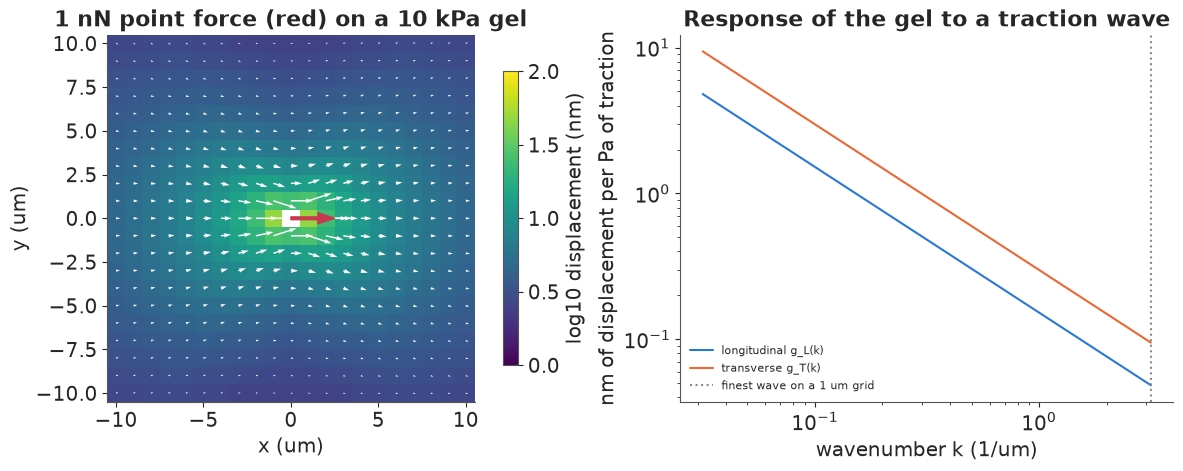

In [2]:
NU = 0.49                                                    # Poisson ratio of the gel


def kgrid(ny, nx, h):
    """Wave vectors of an ny x nx grid with spacing h (um): |k| and the unit vector k/|k|."""
    KX, KY = np.meshgrid(2 * np.pi * np.fft.fftfreq(nx, h), 2 * np.pi * np.fft.fftfreq(ny, h))
    K = np.hypot(KX, KY)
    Ks = np.where(K == 0, 1.0, K)
    return dict(K=K, cx=KX / Ks, cy=KY / Ks, keep=K > 0, h=h)


def to_modes(fx, fy, g):
    """Real vector field -> longitudinal and transverse Fourier modes (unitary transform)."""
    FX, FY = np.fft.fft2(fx, norm="ortho"), np.fft.fft2(fy, norm="ortho")
    return g["cx"] * FX + g["cy"] * FY, g["cy"] * FX - g["cx"] * FY


def from_modes(fL, fT, g):
    fL, fT = np.where(g["keep"], fL, 0), np.where(g["keep"], fT, 0)
    FX, FY = g["cx"] * fL + g["cy"] * fT, g["cy"] * fL - g["cx"] * fT
    return np.fft.ifft2(FX, norm="ortho").real, np.fft.ifft2(FY, norm="ortho").real


def green(g, E, nu=NU):
    """Response of an elastic half-space (um per Pa) to longitudinal / transverse traction modes."""
    Ks = np.where(g["keep"], g["K"], 1.0)
    A = 2 * (1 + nu) / E
    return np.where(g["keep"], A * (1 - nu) / Ks, 0.0), np.where(g["keep"], A / Ks, 0.0)


def forward(tx, ty, g, E):
    gL, gT = green(g, E)
    TL, TT = to_modes(tx, ty, g)
    return from_modes(gL * TL, gT * TT, g)


# a 1 nN point force along x on a 10 kPa gel (the real-space Boussinesq solution)
E10 = 10e3
x1 = np.linspace(-10, 10, 21)
X1, Y1 = np.meshgrid(x1, x1)
R1 = np.hypot(X1, Y1)
R1[R1 == 0] = np.nan
pref = (1 + NU) * 1e3 / (np.pi * E10)                         # 1 nN = 1e3 Pa um^2 -> um
ux1 = pref * ((1 - NU) / R1 + NU * X1**2 / R1**3)
uy1 = pref * NU * X1 * Y1 / R1**3
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axs[0]
im = ax.imshow(np.log10(np.hypot(ux1, uy1) * 1e3), origin="lower", cmap="viridis",
               extent=[-10.5, 10.5, -10.5, 10.5], vmin=0, vmax=2)
ax.quiver(X1, Y1, ux1, uy1, color="white", scale=0.4, width=0.004)
ax.annotate("", xy=(2.5, 0), xytext=(0, 0), arrowprops=dict(color=RED, width=2, headwidth=8))
ax.set(xlabel="x (um)", ylabel="y (um)", title="1 nN point force (red) on a 10 kPa gel")
fig.colorbar(im, ax=ax, shrink=0.8, label="log10 displacement (nm)")
ax = axs[1]
kk = np.logspace(-1.5, np.log10(np.pi), 100)
A10 = 2 * (1 + NU) / E10
ax.loglog(kk, A10 * (1 - NU) / kk * 1e3, color=BLUE, label="longitudinal g_L(k)")
ax.loglog(kk, A10 / kk * 1e3, color=ORANGE, label="transverse g_T(k)")
ax.axvline(np.pi, color=GREY, ls=":", label="finest wave on a 1 um grid")
ax.set(xlabel="wavenumber k (1/um)", ylabel="nm of displacement per Pa of traction",
       title="Response of the gel to a traction wave")
ax.legend(fontsize=8)
print(f"1 nN on 10 kPa: {pref * 1e3:.0f} nm at 1 um along the force, {pref * 1e3 / 10:.1f} nm at 10 um")

Left: the displacement field of a single 1 nN force (a strong focal adhesion pulls with a few
nN). The gel moves by about 47 nm one µm from the force and still by 5 nm ten µm away: the
response falls off only as $1/r$, so every bead feels every adhesion. The field is stronger along
the force than across it (by the factor $1-\nu$). Right: the same fact in Fourier space. Traction
patterns with long wavelengths (small $k$) move the gel a lot; fine patterns barely move it, since
$g(k) \propto 1/k$. Inverting means **dividing by $g$**, i.e. multiplying the measured
displacement modes by $k$: the finer the detail we want, the more the noise in it is amplified.
That is what makes the problem ill-posed. It is only mildly ill-posed (a factor of $k$, not an
exponential as for heat-equation inverse problems), but beads are tracked to about 10 nm while the
signal of a small adhesion is not much more.

## 2 · A simulated cell, and the naive inverse

We build a cell whose forces we know. An elongated cell (an ellipse 40 × 18 µm) on an 8 kPa gel
pulls through **16 focal adhesions** near its edge, all pointing inwards, as the contracting actin
cortex and stress fibres load them: 6 strong ones (2.5-6 nN) at the two tips where stress fibres
end, and 10 weak ones (0.5-1 nN) along the sides. Each adhesion is a 2.5 × 1 µm patch. We compute
the displacements on a grid three times finer than the one we will invert on (so that the
simulation and the inversion do not share their discretisation - the "inverse crime"), sample them
on a 1 µm grid and add 10 nm of tracking noise.

max traction 1450 Pa, max displacement 491 nm, noise sd 10 nm
16 adhesions, total 30.3 nN; footprint 656 pixels of 4096
naive inverse: RMSE 151 Pa (the true field has rms 60 Pa)


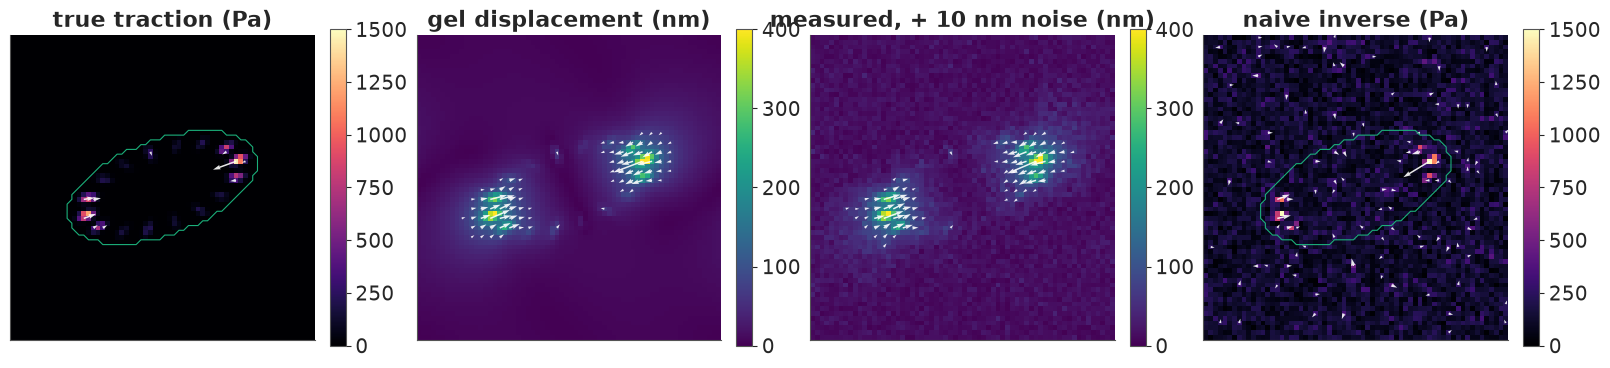

In [3]:
N, H, F = 64, 1.0, 3                                        # 64 x 64 grid of 1 um; fine grid 3x
E_TRUE, SIG_TRUE = 8000.0, 0.010                            # Pa, um (10 nm tracking noise)
Nf, Hf = N * F, H / F
xf = (np.arange(Nf) - Nf / 2 + 0.5) * Hf                     # coarse pixel centres = fine index 3j+1
XF, YF = np.meshgrid(xf, xf)
xc = xf[F // 2::F]
XC, YC = np.meshgrid(xc, xc)
THETA, SEMI_A, SEMI_B = np.deg2rad(20), 20.0, 9.0


def cell_frame(X, Y):
    return X * np.cos(THETA) + Y * np.sin(THETA), -X * np.sin(THETA) + Y * np.cos(THETA)


# adhesions: angle on the rim (cell frame, degrees) and force (nN); all pull towards the centre
ADH_PHI = np.deg2rad([0, 25, -25, 180, 155, 205, 50, 70, 90, 110, 130, 230, 250, 270, 290, 310])
ADH_F = np.array([6.0, 3.0, 3.0, 5.0, 3.5, 2.5, 0.8, 0.6, 1.0, 0.5, 0.8, 0.6, 1.0, 0.5, 0.8, 0.7])
tfx, tfy = np.zeros_like(XF), np.zeros_like(XF)
adh = []
for phi, Fn in zip(ADH_PHI, ADH_F):
    px, py = 0.85 * SEMI_A * np.cos(phi), 0.85 * SEMI_B * np.sin(phi)
    ax_, ay_ = px * np.cos(THETA) - py * np.sin(THETA), px * np.sin(THETA) + py * np.cos(THETA)
    dx_, dy_ = -ax_ / np.hypot(ax_, ay_), -ay_ / np.hypot(ax_, ay_)
    along = (XF - ax_) * dx_ + (YF - ay_) * dy_
    across = -(XF - ax_) * dy_ + (YF - ay_) * dx_
    w = np.exp(-0.5 * (along / 1.0) ** 2 - 0.5 * (across / 0.45) ** 2)
    w /= w.sum() * Hf**2
    tfx += 1e3 * Fn * w * dx_                                 # nN / um^2 = 1000 Pa
    tfy += 1e3 * Fn * w * dy_
    adh.append((ax_, ay_, Fn))
adh = np.array(adh)
support = np.hypot(tfx, tfy) > 1.0                           # remove the small net force (Newton 3)
tfx[support] -= tfx.sum() / support.sum()
tfy[support] -= tfy.sum() / support.sum()

uxf, uyf = forward(tfx, tfy, kgrid(Nf, Nf, Hf), E_TRUE)
ux_true, uy_true = uxf[F // 2::F, F // 2::F], uyf[F // 2::F, F // 2::F]
tx_true = tfx.reshape(N, F, N, F).mean(axis=(1, 3))
ty_true = tfy.reshape(N, F, N, F).mean(axis=(1, 3))
ux_obs = ux_true + SIG_TRUE * rng.standard_normal((N, N))
uy_obs = uy_true + SIG_TRUE * rng.standard_normal((N, N))
ellipse = (cell_frame(XC, YC)[0] / SEMI_A) ** 2 + (cell_frame(XC, YC)[1] / SEMI_B) ** 2 <= 1
FOOT = binary_dilation(ellipse)                              # the cell footprint (+1 pixel)
g = kgrid(N, N, H)
print(f"max traction {np.hypot(tx_true, ty_true).max():.0f} Pa, max displacement "
      f"{np.hypot(ux_true, uy_true).max() * 1e3:.0f} nm, noise sd {SIG_TRUE * 1e3:.0f} nm")
print(f"{len(ADH_F)} adhesions, total {ADH_F.sum():.1f} nN; footprint {FOOT.sum()} pixels of {N * N}")


def show(ax, fx, fy, title, vmax, mask=None, cmap="magma", step=2, extent=None, X=None, Y=None):
    """Magnitude map + arrows (only where the magnitude exceeds 15% of vmax)."""
    X = XC if X is None else X
    Y = YC if Y is None else Y
    if extent is None:
        extent = [xc[0] - H / 2, xc[-1] + H / 2, xc[0] - H / 2, xc[-1] + H / 2]
    im = ax.imshow(np.hypot(fx, fy), origin="lower", cmap=cmap, vmin=0, vmax=vmax, extent=extent)
    sl = (slice(step // 2, None, step),) * 2
    big = np.hypot(fx, fy)[sl] > 0.15 * vmax
    ax.quiver(X[sl][big], Y[sl][big], fx[sl][big], fy[sl][big], color="white", scale=12 * vmax,
              width=0.005, alpha=0.9)
    if mask is not None:
        ax.contour(X, Y, mask, [0.5], colors=[AQUA], linewidths=0.8)
    ax.set(title=title, xticks=[], yticks=[])
    return im


UL, UT = to_modes(ux_obs, uy_obs, g)                          # data, mode by mode
gL, gT = green(g, E_TRUE)
naive = from_modes(np.where(g["keep"], UL / np.where(g["keep"], gL, 1), 0),
                   np.where(g["keep"], UT / np.where(g["keep"], gT, 1), 0), g)


def rmse(fx, fy):
    return np.sqrt(np.mean((fx - tx_true) ** 2 + (fy - ty_true) ** 2))


print(f"naive inverse: RMSE {rmse(*naive):.0f} Pa "
      f"(the true field has rms {np.sqrt(np.mean(tx_true**2 + ty_true**2)):.0f} Pa)")
fig, axs = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, (fx, fy), ttl, vm, cm in zip(
        axs, [(tx_true, ty_true), (ux_true * 1e3, uy_true * 1e3), (ux_obs * 1e3, uy_obs * 1e3), naive],
        ["true traction (Pa)", "gel displacement (nm)", "measured, + 10 nm noise (nm)", "naive inverse (Pa)"],
        [1500, 400, 400, 1500], ["magma", "viridis", "viridis", "magma"]):
    im = show(ax, fx, fy, ttl, vm, mask=FOOT if cm == "magma" else None, cmap=cm)
    fig.colorbar(im, ax=ax, shrink=0.75)

The true tractions (left, cell outline in green) are concentrated in the adhesions; the gel
displacement (second panel) is smooth and spreads far beyond the cell, with the largest movement
under the tip adhesions. With 10 nm of noise (third panel) the displacement map still looks
clean: the noise is a few percent of the signal. The naive inverse (right) recovers the two tip
clusters but covers the whole field in noise of 100-300 Pa, the size of the weak adhesions we
want to see. Its error (RMSE 151 Pa) is two and a half times the rms of the true field (60 Pa).

## 3 · Tikhonov regularisation is a Gaussian prior

The classical fix (Sabass et al. 2008, *Biophys. J.*, for FTTC) is **Tikhonov regularisation**:
minimise $\lVert \mathbf G\mathbf t - \mathbf u\rVert^2 + \lambda \lVert \mathbf t \rVert^2$,
trading fit against the size of the tractions. Divide by $2\sigma^2$ and this is minus the log
posterior of

$$\mathbf u \mid \mathbf t \sim \mathcal N(\mathbf G\mathbf t,\ \sigma^2 I), \qquad
\mathbf t \sim \mathcal N(0,\ s^2 I), \qquad \lambda = \sigma^2 / s^2 ,$$

so the Tikhonov solution is the **posterior mean under a white Gaussian prior** on the tractions.
In Fourier space, mode by mode:

$$\mathbb E[\tilde t \mid \tilde u] = \frac{g\, s^2}{g^2 s^2 + \sigma^2}\,\tilde u, \qquad
\operatorname{Var}[\tilde t \mid \tilde u] = \frac{s^2 \sigma^2}{g^2 s^2 + \sigma^2}.$$

Modes the gel transmits well ($g^2 s^2 \gg \sigma^2$) are inverted; modes buried in noise are
shrunk to the prior mean, zero. The question is how to choose $\lambda$. Three classical answers
and one Bayesian one:

- **L-curve**: plot solution norm against residual norm on log-log axes for many $\lambda$ and pick
  the point of maximum curvature (Hansen's rule, widely used in TFM).
- **Discrepancy principle**: choose $\lambda$ so that the residual norm equals the noise you expect,
  $\sigma\sqrt{n}$. It needs to know $\sigma$.
- **Oracle**: the $\lambda$ that minimises the error against the truth - available only in simulation.
- **Marginal likelihood** (type-II maximum likelihood, ML-II): integrate the tractions out.
  With everything Gaussian, the displacement modes are independent with
  $\tilde u \sim \mathcal N(0,\ g^2 s^2 + \sigma^2)$, so
  $\log p(\mathbf u \mid s, \sigma) = -\tfrac12 \sum_{\text{modes}} \big[\,|\tilde u|^2/(g^2 s^2 + \sigma^2) + \log 2\pi(g^2 s^2 + \sigma^2)\big]$,
  exact because the unitary FFT turns the circulant covariance into a diagonal one. It estimates
  $s$ **and** $\sigma$, hence $\lambda$, from the data alone. Huang et al. (2019, *Sci. Rep.*)
  developed this Bayesian parameter choice for FTTC.

In [4]:
def post_modes(U, gk, s2, sig2):
    """Posterior mean and variance of one family of modes: t ~ N(0, s2), U = g t + N(0, sig2)."""
    den = gk**2 * s2 + sig2
    return gk * s2 / den * U, s2 * sig2 / den


def reconstruct(UL, UT, g, E, s2, sig2):
    gL, gT = green(g, E)
    return from_modes(post_modes(UL, gL, s2, sig2)[0], post_modes(UT, gT, s2, sig2)[0], g)


def log_ml(UL, UT, g, E, s2, sig2):
    """Exact log marginal likelihood of the displacement field (k = 0, the drift, left out)."""
    gL, gT = green(g, E)
    tot = 0.0
    for gk, U in ((gL, UL), (gT, UT)):
        c = (gk**2 * s2 + sig2)[g["keep"]]
        tot -= 0.5 * np.sum(np.abs(U[g["keep"]]) ** 2 / c + np.log(2 * np.pi * c))
    return tot


# Tikhonov path: posterior mean with s2 = 1, sig2 = lambda
lams = np.logspace(-13, -5, 161)                             # um^2 / Pa^2
res_norm, sol_norm, err_lam = [], [], []
for lam in lams:
    mL, _ = post_modes(UL, gL, 1.0, lam)
    mT, _ = post_modes(UT, gT, 1.0, lam)
    rL, rT = (gL * mL - UL)[g["keep"]], (gT * mT - UT)[g["keep"]]
    res_norm.append(np.sqrt(np.sum(np.abs(rL) ** 2 + np.abs(rT) ** 2)))
    sol_norm.append(np.sqrt(np.sum(np.abs(mL) ** 2 + np.abs(mT) ** 2)))
    err_lam.append(rmse(*from_modes(mL, mT, g)))
res_norm, sol_norm, err_lam = map(np.array, (res_norm, sol_norm, err_lam))
lr, lsn = np.log(res_norm), np.log(sol_norm)
d1r, d1s = np.gradient(lr), np.gradient(lsn)
curv = (d1r * np.gradient(d1s) - np.gradient(d1r) * d1s) / (d1r**2 + d1s**2) ** 1.5
inner = slice(3, -3)
i_max = np.argmax(curv[inner]) + 3                            # textbook rule: max (signed) curvature
i_bend = np.argmax(np.abs(curv[inner])) + 3                   # the visible bend of the curve
n_modes = 2 * (N * N - 1)
i_disc = np.argmin(np.abs(res_norm - SIG_TRUE * np.sqrt(n_modes)))
sig_grid, s_grid = np.logspace(-2.5, -1.5, 41), np.logspace(1, 4, 121)
LML = np.array([[log_ml(UL, UT, g, E_TRUE, s**2, sg**2) for s in s_grid] for sg in sig_grid])
i_sg, i_s = np.unravel_index(LML.argmax(), LML.shape)
LAM = {"L-curve, max curvature": lams[i_max], "L-curve, bend": lams[i_bend],
       "discrepancy (true σ)": lams[i_disc], "marginal likelihood": (sig_grid[i_sg] / s_grid[i_s]) ** 2,
       "oracle": lams[np.argmin(err_lam)]}
LAM_COL = [GREY, RED, PURPLE, BLUE, AQUA]
for k_, lam in LAM.items():
    print(f"{k_:>24}: lambda = {lam:.1e} um^2/Pa^2, RMSE = {rmse(*reconstruct(UL, UT, g, E_TRUE, 1.0, lam)):.0f} Pa")
print(f"ML-II: noise sd {sig_grid[i_sg] * 1e3:.1f} nm (true {SIG_TRUE * 1e3:.0f}), traction sd {s_grid[i_s]:.0f} Pa")
# the textbook rule depends on the lambda range scanned:
for lo in (-12, -10):
    sel = lams >= 10.0**lo
    print(f"max-curvature rule scanning lambda from 1e{lo}: picks {lams[sel][np.argmax(curv[sel][3:-3]) + 3]:.1e}")

  L-curve, max curvature: lambda = 1.4e-13 um^2/Pa^2, RMSE = 151 Pa
           L-curve, bend: lambda = 8.9e-09 um^2/Pa^2, RMSE = 66 Pa
    discrepancy (true σ): lambda = 8.9e-08 um^2/Pa^2, RMSE = 38 Pa
     marginal likelihood: lambda = 1.1e-08 um^2/Pa^2, RMSE = 60 Pa
                  oracle: lambda = 5.6e-08 um^2/Pa^2, RMSE = 37 Pa
ML-II: noise sd 7.9 nm (true 10), traction sd 75 Pa
max-curvature rule scanning lambda from 1e-12: picks 1.4e-12
max-curvature rule scanning lambda from 1e-10: picks 3.5e-07


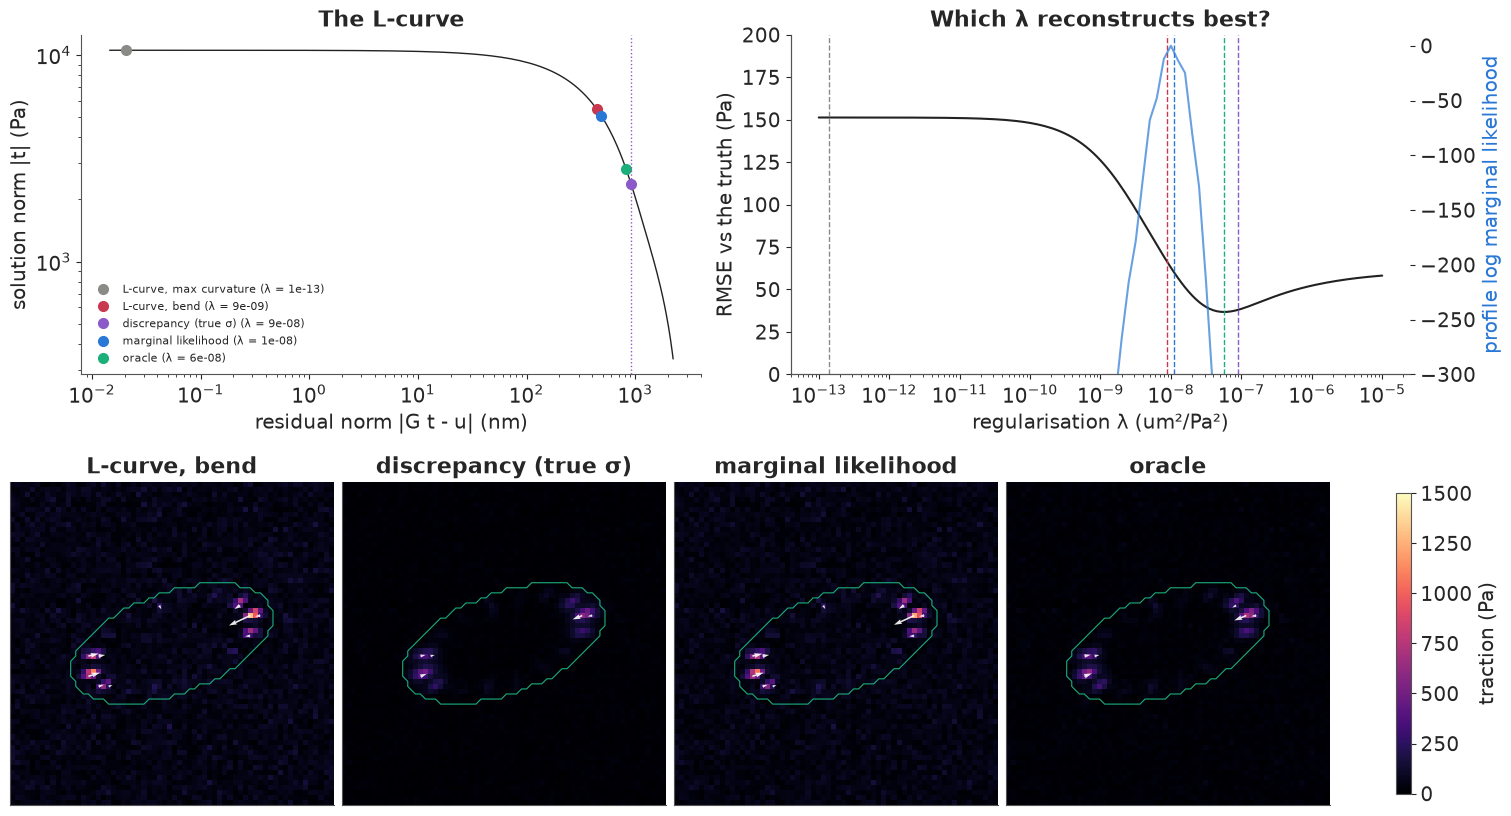

In [5]:
fig = plt.figure(figsize=(15, 8.3))
top, bot = fig.subfigures(2, 1, height_ratios=[1, 0.9])
axs = top.subplots(1, 2)
ax = axs[0]
ax.loglog(res_norm * 1e3, sol_norm, color=INK, lw=1)
for (k_, lam), c in zip(LAM.items(), LAM_COL):
    j = np.argmin(np.abs(np.log(lams / lam)))
    ax.plot(res_norm[j] * 1e3, sol_norm[j], "o", color=c, ms=7, label=f"{k_} (λ = {lam:.0e})")
ax.axvline(SIG_TRUE * np.sqrt(n_modes) * 1e3, color=PURPLE, ls=":", lw=1)
ax.set(xlabel="residual norm |G t - u| (nm)", ylabel="solution norm |t| (Pa)", title="The L-curve")
ax.legend(fontsize=8, loc="lower left")
ax = axs[1]
ax.semilogx(lams, err_lam, color=INK, label="RMSE vs the truth")
for (k_, lam), c in zip(LAM.items(), LAM_COL):
    ax.axvline(lam, color=c, ls="--", lw=1)
ax.set(xlabel="regularisation λ (um²/Pa²)", ylabel="RMSE vs the truth (Pa)", ylim=(0, 200),
       title="Which λ reconstructs best?")
ax2 = ax.twinx()
prof = np.array([max(log_ml(UL, UT, g, E_TRUE, sg**2 / lam, sg**2) for sg in sig_grid[::2]) for lam in lams[::2]])
ax2.semilogx(lams[::2], prof - prof.max(), color=BLUE, alpha=0.7)
ax2.set_ylim(-300, 10)
ax2.set_ylabel("profile log marginal likelihood", color=BLUE)
axs = bot.subplots(1, 4)
for ax, k_ in zip(axs, list(LAM)[1:]):
    im = show(ax, *reconstruct(UL, UT, g, E_TRUE, 1.0, LAM[k_]), k_, 1500, mask=FOOT)
bot.colorbar(im, ax=axs, shrink=0.8, label="traction (Pa)");

The L-curve (top left) is not an L here. For small $\lambda$ the solution norm levels off (on a
finite grid the noise amplification is bounded by the finest wave, $k = \pi$/µm), and for large
$\lambda$ it drops: the curve is a bent arc with no convex corner. The textbook rule "maximum
curvature" then has nothing to find and picks an end of whatever $\lambda$ range you scan (grey:
$10^{-13}$, $10^{-12}$ or $3.5 \times 10^{-7}$ depending on where the scan starts, printout). The
visible bend (red, $\lambda \approx 9 \times 10^{-9}$) is a reasonable choice, and it lands close to
the marginal-likelihood $\lambda$ (blue, $1.1 \times 10^{-8}$). Both leave the reconstruction a little
noisy (bottom row; RMSE 66 and 60 Pa). The **discrepancy principle** (purple: the residual equals
the expected noise norm, dotted line) lands next to the **oracle** (green; RMSE 38 vs 37 Pa),
because it was given the true $\sigma$. Both smooth enough to remove the background, but they also
fade the weak side adhesions. The profile marginal likelihood (right, blue curve) is sharply
peaked: the data are informative about $\lambda$.

ML-II with a white prior does worse than the oracle, and it underestimates the noise (7.9 nm
instead of 10). The white prior is wrong for this cell: it says tractions
are independent from pixel to pixel with one common scale, while real tractions are smooth over an
adhesion and zero almost everywhere. The marginal likelihood can only choose the best $\lambda$
*within the model it is given*. So the next step is not a better rule for $\lambda$ but a better
prior.

## 4 · Full Bayes over the hyperparameters, and what the posterior says about a cell

A Gaussian process prior on the traction field is also diagonal in Fourier space: a stationary
covariance kernel becomes a **spectrum** $s^2(k)$, the prior variance of each mode. The white prior
is a flat spectrum. A **smooth** prior (squared-exponential kernel with length scale $\ell$) is
$s^2(k) = s_0^2\, e^{-k^2 \ell^2/2}$: it says that traction patterns finer than $\ell$ are unlikely.
The marginal likelihood keeps its closed form with $s^2 \to s^2(k)$. In PyMC we can therefore
sample the **hyperparameters** $(\sigma, s_0, \ell)$ with NUTS, with the $2 \times 4{,}095$ traction
modes integrated out exactly (a `pm.Potential` of the log marginal likelihood). Given each
hyperparameter draw, the traction field is Gaussian with the mode-by-mode mean and variance above,
so we can add exact **joint posterior draws of the whole field** in NumPy: draw white noise, FFT,
scale by the posterior sd of each mode, add the mean, transform back.

In [6]:
def prior_s2(K, log_s, log_ell=None, log_alpha=None, lib=np):
    """Prior spectrum of the traction modes: white, squared-exponential, or Matern-like."""
    if log_ell is None:
        return lib.exp(2 * log_s) + 0 * K
    if log_alpha is None:
        return lib.exp(2 * log_s - 0.5 * (K * lib.exp(log_ell)) ** 2)
    return lib.exp(2 * log_s) * (1 + (K * lib.exp(log_ell)) ** 2) ** (-lib.exp(log_alpha))


def fit_hyper(UL, UT, g, E, prior, sig0=0.01, s0=300.0, ell0=2.0):
    """NUTS on the hyperparameters with the traction field integrated out (exact, in Fourier space)."""
    keep = g["keep"]
    Kk = g["K"][keep]
    gL, gT = green(g, E)
    obs = [(gL[keep], np.abs(UL[keep]) ** 2), (gT[keep], np.abs(UT[keep]) ** 2)]
    with pm.Model():
        log_sig = pm.Normal("log_sig", np.log(sig0), 1.0)      # noise sd (um)
        log_s = pm.Normal("log_s", np.log(s0), 1.5)            # traction scale (Pa)
        log_ell = pm.Normal("log_ell", np.log(ell0), 1.0) if prior != "white" else None
        log_alpha = pm.Normal("log_alpha", 0.0, 0.7) if prior == "matern" else None
        s2 = prior_s2(Kk, log_s, log_ell, log_alpha, lib=pt)
        ll = 0.0
        for gk, a2 in obs:
            c = gk**2 * s2 + pt.exp(2 * log_sig)
            ll = ll - 0.5 * pt.sum(a2 / c + pt.log(2 * np.pi * c))
        pm.Potential("log_ml", ll)
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    return idata


def draw_tractions(UL, UT, g, E, idata, n, seed):
    """Joint posterior draws of the traction field: hyperparameters from NUTS, field given them exactly."""
    r = np.random.default_rng(seed)
    post = {k_: idata.posterior[k_].values.ravel() for k_ in idata.posterior.data_vars}
    idx = r.choice(len(post["log_s"]), n, replace=False)
    gL, gT = green(g, E)
    ny, nx = g["K"].shape
    out = np.empty((n, 2, ny, nx))
    for j, i in enumerate(idx):
        s2 = prior_s2(g["K"], *(post[v][i] if v in post else None for v in ("log_s", "log_ell", "log_alpha")))
        sig2 = np.exp(2 * post["log_sig"][i])
        mL, vL = post_modes(UL, gL, s2, sig2)
        mT, vT = post_modes(UT, gT, s2, sig2)
        zL, zT = to_modes(r.standard_normal((ny, nx)), r.standard_normal((ny, nx)), g)
        out[j] = from_modes(mL + np.sqrt(vL) * zL, mT + np.sqrt(vT) * zT, g)
    return out


def max_log_ml(UL, UT, g, E, prior, p0):
    """ML-II: maximise the log marginal likelihood over (log sigma, log s, [log ell, [log alpha]])."""
    def nll(p):
        s2 = prior_s2(g["K"], *p[1:], *([None] * (4 - len(p))))
        return -log_ml(UL, UT, g, E, s2, np.exp(2 * p[0]))
    r = minimize(nll, p0, method="Nelder-Mead", options=dict(xatol=1e-5, fatol=1e-4, maxiter=6000))
    return -r.fun, r.x


def report(idata, name):
    print(f"--- {name}: {int(idata.sample_stats['diverging'].sum())} divergences, "
          f"{idata.posterior.attrs.get('tuning_steps', '?')} tuning steps (nutpie)")
    print(az.summary(idata, round_to=4, ci_prob=0.94)[["mean", "sd", "eti94_lb", "eti94_ub", "ess_bulk",
                                                       "r_hat"]].to_string())


t0 = time.time()
id_white = fit_hyper(UL, UT, g, E_TRUE, "white")
id_smooth = fit_hyper(UL, UT, g, E_TRUE, "smooth")
print(f"both fits: {time.time() - t0:.0f} s")
report(id_white, "white prior")
report(id_smooth, "smooth prior")
psm = id_smooth.posterior
print(f"smooth prior: noise sd {np.exp(psm['log_sig']).mean().item() * 1e3:.2f} nm, amplitude "
      f"{np.exp(psm['log_s']).mean().item():.0f} Pa, length scale {np.exp(psm['log_ell']).mean().item():.2f} um")
lml_w, _ = max_log_ml(UL, UT, g, E_TRUE, "white", [np.log(0.01), np.log(100)])
lml_s, _ = max_log_ml(UL, UT, g, E_TRUE, "smooth", [np.log(0.01), np.log(200), np.log(1.5)])
print(f"max log marginal likelihood: white {lml_w:.0f}, smooth {lml_s:.0f} (difference {lml_s - lml_w:.0f})")

both fits: 3 s
--- white prior: 0 divergences, 400 tuning steps (nutpie)
           mean      sd  eti94_lb  eti94_ub   ess_bulk   r_hat
log_sig -4.8455  0.0171   -4.8763   -4.8133  2491.5714  1.0002
log_s    4.3406  0.0147    4.3133    4.3680  2533.9411  1.0014
--- smooth prior: 0 divergences, 400 tuning steps (nutpie)
           mean      sd  eti94_lb  eti94_ub   ess_bulk   r_hat
log_sig -4.6406  0.0137   -4.6663   -4.6149  1901.7741  1.0026
log_s    4.5989  0.0265    4.5497    4.6499  1581.7855  1.0023
log_ell -0.3009  0.0439   -0.3848   -0.2192  1539.0275  1.0021
smooth prior: noise sd 9.65 nm, amplitude 99 Pa, length scale 0.74 um
max log marginal likelihood: white 23838, smooth 23957 (difference 119)


Both fits take a few seconds, with no divergences, $\hat R \le 1.003$ and bulk ESS above 1,500.
The posteriors of the hyperparameters are very narrow: 8,190 modes are a lot of data about two or
three numbers, so full Bayes and ML-II give practically the same answer here, and the uncertainty
about $\lambda$ adds almost nothing to the uncertainty about the forces. With the smooth prior the
noise estimate is nearly right (9.7 nm, true 10). Its length scale comes out at 0.74 µm, below the
grid spacing: the prior mostly damps the finest waves on the grid, which is where the noise lives,
while leaving adhesion-sized patterns (1-2.5 µm) alone. Its log marginal likelihood is 119 units
higher than the white prior's, an overwhelming preference (a log Bayes factor, up to the small
difference the narrow hyperparameter posteriors make).

What do biologists report from a traction map? Mostly single numbers that summarise how hard a
cell pulls (Butler et al. 2002):

- the **strain energy** $U = \tfrac12 \int \mathbf t\cdot\mathbf u\, dA$, the elastic work the cell has
  done on the gel (in fJ = $10^{-15}$ J);
- the **net contractile moment** $-\operatorname{tr} \int \mathbf x\, \mathbf t^\top dA$, which measures
  how strongly the forces point inwards (in nN·µm);
- the **total force** $\int |\mathbf t|\, dA$ (in nN).

Each is computed per posterior draw of the field over a region around the cell (the footprint
grown by 4 µm), which gives credible intervals.

In [7]:
def strain_energy(fx, fy, ux, uy, mask, h):
    """U = 1/2 sum t.u dA over the mask, in fJ (Pa um^3 = 1e-18 J)."""
    return 0.5 * np.sum(((fx * ux + fy * uy) * mask).reshape(*fx.shape[:-2], -1), axis=-1) * h**2 * 1e-3


def total_force(fx, fy, mask, h):
    """Sum of traction magnitudes over the mask, in nN."""
    return np.sum((np.hypot(fx, fy) * mask).reshape(*fx.shape[:-2], -1), axis=-1) * h**2 * 1e-3


def contractile_moment(fx, fy, mask, X, Y, h):
    """Net contractile moment: minus the trace of the first moment of the tractions, in nN um."""
    return -np.sum(((X * fx + Y * fy) * mask).reshape(*fx.shape[:-2], -1), axis=-1) * h**2 * 1e-3


ROI = binary_dilation(FOOT, iterations=4)
ux_c, uy_c = ux_obs - ux_obs.mean(), uy_obs - uy_obs.mean()
QTY = {"U": "strain energy (fJ)", "M": "contractile moment (nN um)", "F": "total force (nN)"}
TRUTH = dict(U=strain_energy(tx_true, ty_true, ux_true, uy_true, ROI, H),
             M=contractile_moment(tx_true, ty_true, ROI, XC, YC, H),
             F=total_force(tx_true, ty_true, ROI, H))


def summaries(td):
    return dict(U=strain_energy(td[:, 0], td[:, 1], ux_c, uy_c, ROI, H),
                M=contractile_moment(td[:, 0], td[:, 1], ROI, XC, YC, H),
                F=total_force(td[:, 0], td[:, 1], ROI, H))


def print_summaries(name, td):
    sm = summaries(td)
    print(f"{name}: RMSE of the posterior mean {rmse(*td.mean(0)):.0f} Pa")
    for q, lab in QTY.items():
        lo, hi = np.quantile(sm[q], [0.055, 0.945])
        print(f"   {lab:>27}: {sm[q].mean():6.1f}  89% [{lo:6.1f}, {hi:6.1f}]   truth {TRUTH[q]:6.1f}")
    return sm


tw = draw_tractions(UL, UT, g, E_TRUE, id_white, 400, RANDOM_SEED)
tsm = draw_tractions(UL, UT, g, E_TRUE, id_smooth, 400, RANDOM_SEED + 1)
SUM = {"white prior": print_summaries("white prior", tw), "smooth prior": print_summaries("smooth prior", tsm)}

white prior: RMSE of the posterior mean 62 Pa
            strain energy (fJ):    3.6  89% [   3.6,    3.7]   truth    3.4
    contractile moment (nN um):  453.4  89% [ 441.8,  464.7]   truth  450.1
              total force (nN):  106.8  89% [ 104.0,  109.3]   truth   30.4
smooth prior: RMSE of the posterior mean 35 Pa
            strain energy (fJ):    3.2  89% [   3.2,    3.3]   truth    3.4
    contractile moment (nN um):  453.9  89% [ 443.7,  465.0]   truth  450.1
              total force (nN):   74.5  89% [  71.6,   77.6]   truth   30.4


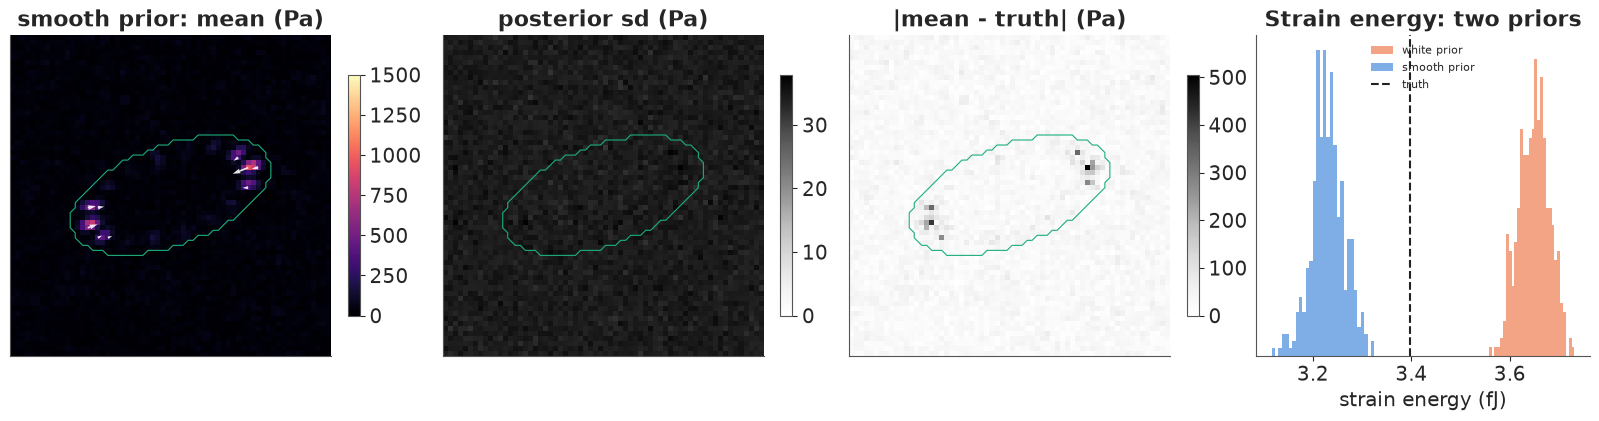

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.1))
im = show(axs[0], *tsm.mean(0), "smooth prior: mean (Pa)", 1500, mask=FOOT)
fig.colorbar(im, ax=axs[0], shrink=0.75)
ext = [xc[0] - H / 2, xc[-1] + H / 2, xc[0] - H / 2, xc[-1] + H / 2]
im = axs[1].imshow(np.sqrt((tsm[:, 0].var(0) + tsm[:, 1].var(0)) / 2), origin="lower", cmap="Greys",
                   vmin=0, extent=ext)
axs[1].contour(XC, YC, FOOT, [0.5], colors=[AQUA], linewidths=0.8)
axs[1].set(title="posterior sd (Pa)", xticks=[], yticks=[])
fig.colorbar(im, ax=axs[1], shrink=0.75)
im = axs[2].imshow(np.hypot(*(tsm.mean(0) - np.stack([tx_true, ty_true]))), origin="lower", cmap="Greys",
                   vmin=0, extent=ext)
axs[2].contour(XC, YC, FOOT, [0.5], colors=[AQUA], linewidths=0.8)
axs[2].set(title="|mean - truth| (Pa)", xticks=[], yticks=[])
fig.colorbar(im, ax=axs[2], shrink=0.75)
ax = axs[3]
for (nm, sm), c in zip(SUM.items(), [ORANGE, BLUE]):
    ax.hist(sm["U"], bins=30, color=c, alpha=0.6, density=True, label=nm)
ax.axvline(TRUTH["U"], color=INK, ls="--", label="truth")
ax.set(xlabel="strain energy (fJ)", yticks=[], title="Strain energy: two priors")
ax.legend(fontsize=8);

The smooth prior's posterior mean (left) recovers both tip clusters and a few of the weak side
adhesions, with little background noise. Its RMSE (35 Pa) is a little lower than that of the
oracle Tikhonov $\lambda$ (37 Pa), which needed the truth to tune: a better prior, tuned by the data
alone, matches the best possible tuning of a worse one. The tip peaks are too low (946 Pa vs 1,450,
section 6).

The posterior sd map (second panel) is **flat**: the same value at every pixel. That is not a
bug. A stationary prior with a stationary noise model has a circulant posterior covariance, so
every pixel is equally uncertain, inside the cell or far outside it. The map of the actual error
(third panel) is anything but flat: the error sits at the adhesions, where the prior's smoothness
is most wrong. A Gaussian stationary posterior cannot tell you *where* it is wrong.

The summaries (printout, right panel) show the same thing for single numbers. The **contractile
moment** is linear in the tractions and well recovered by both priors (453-454 nN·µm, truth 450),
with intervals that contain the truth. The **strain energy** intervals are narrow (a few percent)
and both miss the truth (3.4 fJ), in opposite directions: the white prior's noisy field adds
energy (3.6), the smooth prior's flattened peaks lose it (3.2). The **total force** $\int|\mathbf t|$
is badly biased upwards (107 and 75 nN against 30): every noisy pixel contributes a positive
$|\mathbf t|$, whatever its direction. Credible intervals
are conditional on the prior; for quantities that depend nonlinearly on the fine structure, the
prior's bias can be far larger than the posterior width.

## 5 · The gel is uncertain too: Young's modulus

Everything so far assumed we know $E$. In practice the gel's stiffness is measured separately, by
atomic force microscopy (AFM) indentation or bulk rheology, and is often uncertain by 10-20%:
gels vary from batch to batch and even across one gel. Because $g \propto 1/E$, **every traction
scales exactly with $E$**. The displacements carry no information about $E$ at all (a stiffer gel
with proportionally larger forces gives identical displacements), so the posterior of $E$ is its
prior, and its uncertainty propagates to every force estimate one-for-one. Suppose the AFM said
8.8 kPa ± 15% (true: 8 kPa). We refit with $E = 8.8$ kPa and then multiply each posterior draw by a
draw of $E / 8.8$ kPa.

         strain energy (fJ): relative sd 0.010 from the displacements, 0.160 with E uncertain (100% of the variance from E); 89% [2.8, 4.6], truth 3.4
 contractile moment (nN um): relative sd 0.016 from the displacements, 0.157 with E uncertain (99% of the variance from E); 89% [401.6, 660.3], truth 450.1
           total force (nN): relative sd 0.026 from the displacements, 0.163 with E uncertain (97% of the variance from E); 89% [65.2, 106.6], truth 30.4


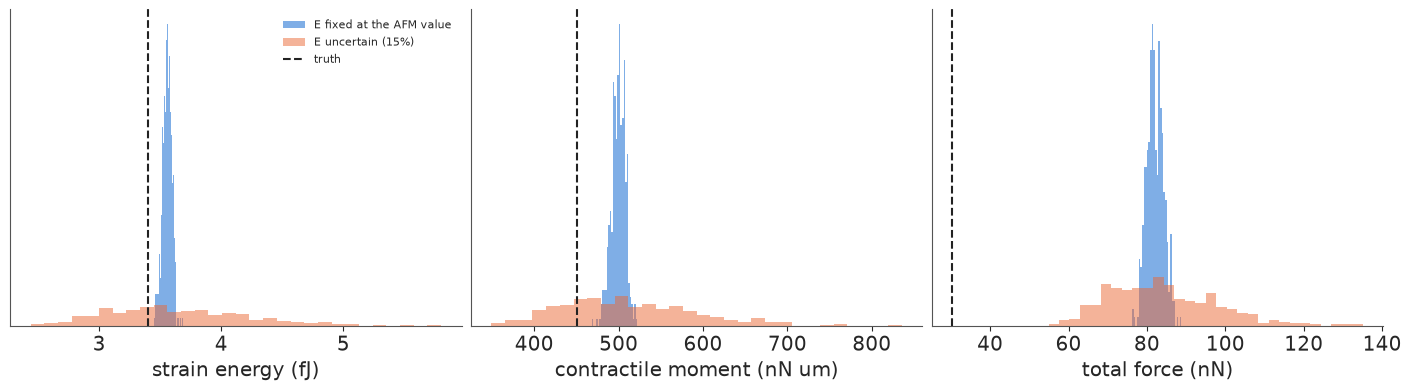

In [9]:
E_AFM, E_CV = 8800.0, 0.15
E_draws = E_AFM * np.exp(E_CV * np.random.default_rng(RANDOM_SEED + 5).standard_normal(400))
id_afm = fit_hyper(UL, UT, g, E_AFM, "smooth")
s_fixed = summaries(draw_tractions(UL, UT, g, E_AFM, id_afm, 400, RANDOM_SEED + 2))
s_unc = {k_: v_ * E_draws / E_AFM for k_, v_ in s_fixed.items()}   # tractions scale exactly with E
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (q, lab) in zip(axs, QTY.items()):
    ax.hist(s_fixed[q], bins=30, color=BLUE, alpha=0.6, density=True, label="E fixed at the AFM value")
    ax.hist(s_unc[q], bins=30, color=ORANGE, alpha=0.5, density=True, label="E uncertain (15%)")
    ax.axvline(TRUTH[q], color=INK, ls="--", label="truth")
    ax.set(xlabel=lab, yticks=[])
axs[0].legend(fontsize=8)
for q, lab in QTY.items():
    cv_meas, cv_tot = s_fixed[q].std() / s_fixed[q].mean(), s_unc[q].std() / s_unc[q].mean()
    lo, hi = np.quantile(s_unc[q], [0.055, 0.945])
    print(f"{lab:>27}: relative sd {cv_meas:.3f} from the displacements, {cv_tot:.3f} with E uncertain "
          f"({1 - cv_meas**2 / cv_tot**2:.0%} of the variance from E); 89% [{lo:.1f}, {hi:.1f}], truth {TRUTH[q]:.1f}")

With $E$ fixed at the (10% too high) AFM value, all three summaries are confidently wrong: the blue
histograms sit about 10% above where the correct $E$ would put them, and every interval excludes
the truth. With a 15% uncertainty on $E$ (orange) the relative sd grows from 1-3% to 16%, the
strain energy and contractile moment intervals include the truth, and **97-100% of the variance
comes from $E$** (printout). The total force stays wrong: no uncertainty about $E$ repairs a biased
summary. For comparing cells on the same gel, $E$ cancels in ratios;
for comparing labs, gels, or absolute forces against a model, the stiffness measurement is the
dominant error, and a TFM paper that reports forces without it is reporting a lower bound on the
uncertainty.

## 6 · Priors that know about cells: the footprint and sparse adhesions

A cell can only pull where it touches the gel. If we know the **footprint** (from a
phase-contrast or membrane image, as we usually do), we can set the tractions outside it to zero.
Butler et al. (2002) did this iteratively ("constrained FTTC"); in the Bayesian view it is a prior
with zero variance outside the mask. The problem is no longer diagonal in Fourier space, but it is
small: 2 × 656 unknown components inside the footprint, against 8,192 measured displacement
components. We build the matrix $\mathbf A$ that maps footprint tractions to all displacements
(one FFT-computed Green's function, shifted to each pixel), and the Gaussian posterior and its
marginal likelihood follow from a 1,312 × 1,312 Cholesky factorisation.

A second piece of biology: tractions are **sparse**. Most of the footprint transmits almost no
force; a few adhesions transmit a lot. A Gaussian prior with one scale cannot say that. A
**regularised horseshoe** prior (Carvalho, Polson & Scott 2010; Piironen & Vehtari 2017) gives each
pixel its own scale $\lambda_i$ (shared by the $x$ and $y$ components, since an adhesion pulls in some
direction), a global scale $\tau$, and a "slab" $c$ that caps the largest tractions at a few kPa:

$$t_{i,x}, t_{i,y} \sim \mathcal N\big(0,\ \tau^2 \tilde\lambda_i^2\big), \quad
\tilde\lambda_i^2 = \frac{c^2\lambda_i^2}{c^2 + \tau^2\lambda_i^2}, \quad
\lambda_i \sim \text{Half-Cauchy}(1),\ \tau \sim \text{Half-Cauchy}(10\ \text{Pa}),\ c^2 \sim \text{Inv-Gamma}(2,\ 2\cdot(1\ \text{kPa})^2).$$

That posterior has no closed form, so NUTS samples all 1,312 traction components, 656 local scales
and three global parameters. To make each gradient cheap we reduce the data to a **sufficient
statistic**: with $\mathbf A^\top\mathbf A = \mathbf L\mathbf L^\top$,
$\lVert\mathbf u - \mathbf A\mathbf t\rVert^2 = \lVert \mathbf L^{-1}\mathbf A^\top\mathbf u - \mathbf L^\top\mathbf t\rVert^2 + \text{const}$,
a 1,312-vector instead of 8,192 displacements (the constant still informs $\sigma$).

In [10]:
iy, ix = np.nonzero(FOOT)
M_PIX = int(FOOT.sum())


def unit_response(ex, ey):
    """Displacement field (um) from 1 Pa of traction in pixel (0, 0)."""
    tx_, ty_ = np.zeros((N, N)), np.zeros((N, N))
    tx_[0, 0], ty_[0, 0] = ex, ey
    return forward(tx_, ty_, g, E_TRUE)


cols = []
for resp in (unit_response(1.0, 0.0), unit_response(0.0, 1.0)):
    for r_, c_ in zip(iy, ix):
        cols.append(np.concatenate([np.roll(resp[0], (r_, c_), (0, 1)).ravel(),
                                    np.roll(resp[1], (r_, c_), (0, 1)).ravel()]))
Amat = np.array(cols).T                                      # (2 N^2) x (2 M), um per Pa
del cols
u_vec = np.concatenate([ux_c.ravel(), uy_c.ravel()])
AtA, Atu, n_obs = Amat.T @ Amat, Amat.T @ u_vec, u_vec.size
del Amat


def masked_gauss(s2, sig2):
    """Posterior mean, Cholesky factor of the posterior precision, and log marginal likelihood."""
    Pm = AtA / sig2 + np.eye(2 * M_PIX) / s2
    Lc = np.linalg.cholesky(Pm)
    mu = np.linalg.solve(Pm, Atu / sig2)
    logml = -0.5 * (u_vec @ u_vec / sig2 - mu @ Atu / sig2 + 2 * np.log(np.diag(Lc)).sum()
                    + 2 * M_PIX * np.log(s2) + n_obs * np.log(2 * np.pi * sig2))
    return mu, Lc, logml


def to_field(v):
    """(..., 2M) vector of footprint tractions -> (..., 2, N, N) field."""
    out = np.zeros(v.shape[:-1] + (2, N, N))
    out[..., 0, iy, ix] = v[..., :M_PIX]
    out[..., 1, iy, ix] = v[..., M_PIX:]
    return out


r6 = minimize(lambda p: -masked_gauss(np.exp(2 * p[1]), np.exp(2 * p[0]))[2], [np.log(0.01), np.log(150)],
              method="Nelder-Mead", options=dict(xatol=1e-3, fatol=1e-2))
sig_m, s_m = np.exp(r6.x)
mu_m, L_m, _ = masked_gauss(s_m**2, sig_m**2)
z6 = np.random.default_rng(RANDOM_SEED + 6).standard_normal((2 * M_PIX, 400))
tmask = to_field((mu_m[:, None] + np.linalg.solve(L_m.T, z6)).T)   # draws from N(mu, P^-1)
print(f"footprint + Gaussian (ML-II): noise sd {sig_m * 1e3:.2f} nm, traction sd {s_m:.0f} Pa")

footprint + Gaussian (ML-II): noise sd 9.83 nm, traction sd 141 Pa


In [11]:
L_f = np.linalg.cholesky(AtA)
y_star = np.linalg.solve(L_f, Atu)                           # |u - A t|^2 = |y* - L^T t|^2 + rss_perp
rss_perp = u_vec @ u_vec - y_star @ y_star
with pm.Model(coords={"comp": ["x", "y"], "pix": np.arange(M_PIX)}) as hs_model:
    sig = pm.LogNormal("sig", np.log(0.01), 0.5)
    tau = pm.HalfCauchy("tau", 10.0)
    lam = pm.HalfCauchy("lam", 1.0, dims="pix")
    c2 = pm.InverseGamma("c2", 2.0, 2.0 * 1000.0**2)
    lam_t = pt.sqrt(c2 * lam**2 / (c2 + tau**2 * lam**2))
    z = pm.Normal("z", 0.0, 1.0, dims=("comp", "pix"))
    t_vec = (z * tau * lam_t).reshape((2 * M_PIX,))
    pm.Normal("y_star", mu=pt.dot(L_f.T, t_vec), sigma=sig, observed=y_star)
    pm.Potential("rest", -(n_obs - 2 * M_PIX) * pt.log(sig) - rss_perp / (2 * sig**2))
    t0 = time.time()
    id_hs = pm.sample(random_seed=RANDOM_SEED, target_accept=0.95, progressbar=False)
print(f"horseshoe: {time.time() - t0:.0f} s, {int(id_hs.sample_stats['diverging'].sum())} divergences, "
      f"tree depths {np.bincount(id_hs.sample_stats['depth'].values.ravel())}")
rh, es = az.rhat(id_hs), az.ess(id_hs)
for v_ in ("sig", "tau", "c2", "lam", "z"):
    print(f"  {v_:>4}: max r_hat {float(rh[v_].max()):.3f}, min bulk ESS {float(es[v_].min()):.0f}")
ph = id_hs.posterior
lt = np.sqrt(ph["c2"].values[..., None] * ph["lam"].values ** 2
             / (ph["c2"].values[..., None] + ph["tau"].values[..., None] ** 2 * ph["lam"].values ** 2))
hs_vec = (ph["z"].values * (ph["tau"].values[..., None] * lt)[:, :, None, :]).reshape(-1, 2 * M_PIX)
ths = to_field(hs_vec[:: len(hs_vec) // 400][:400])
print(f"horseshoe: noise sd {ph['sig'].mean().item() * 1e3:.2f} nm, tau {ph['tau'].mean().item():.1f} Pa")
del hs_vec, lt

horseshoe: 61 s, 0 divergences, tree depths [   0    0    0    0    0    0    0 4000]


   sig: max r_hat 1.000, min bulk ESS 6368
   tau: max r_hat 1.025, min bulk ESS 220
    c2: max r_hat 1.009, min bulk ESS 207
   lam: max r_hat 1.030, min bulk ESS 96
     z: max r_hat 1.023, min bulk ESS 143
horseshoe: noise sd 9.87 nm, tau 16.2 Pa


In [12]:
def adhesion_forces(fx, fy, radius=1.5):
    """Force (nN) within `radius` um of each adhesion centre: |sum t dA|."""
    out = []
    for ax_, ay_, _ in adh:
        sel = np.hypot(XC - ax_, YC - ay_) <= radius
        out.append(np.hypot(fx[..., sel].sum(-1), fy[..., sel].sum(-1)) * H**2 * 1e-3)
    return np.stack(out, axis=-1)


METHODS = {"white prior": tw, "smooth prior": tsm, "footprint + Gaussian": tmask, "footprint + horseshoe": ths}
F_true = adhesion_forces(tx_true, ty_true)
weak = ADH_F <= 1.0
for nm, td in METHODS.items():
    mean = td.mean(0)
    af = adhesion_forces(td[:, 0], td[:, 1])
    lo, hi = np.quantile(af, [0.055, 0.945], axis=0)
    sm = summaries(td)
    print(f"{nm:>21}: RMSE {rmse(*mean):3.0f} Pa | peak {np.hypot(*mean).max():4.0f} Pa (true "
          f"{np.hypot(tx_true, ty_true).max():.0f}) | outside the cell "
          f"{total_force(*mean, ~FOOT, H) / total_force(*mean, np.ones_like(FOOT), H):4.0%} | weak adhesions: "
          f"mean |error| {np.mean(np.abs(af.mean(0) - F_true)[weak]):.2f} nN, 89% coverage "
          f"{np.mean(((lo <= F_true) & (F_true <= hi))[weak]):.0%}")
    print(" " * 23 + " | ".join(f"{QTY[q].split(' (')[0]} {sm[q].mean():.1f} [{np.quantile(sm[q], 0.055):.1f}, "
                                f"{np.quantile(sm[q], 0.945):.1f}] (true {TRUTH[q]:.1f})" for q in QTY))

          white prior: RMSE  62 Pa | peak 1259 Pa (true 1450) | outside the cell  77% | weak adhesions: mean |error| 0.08 nN, 89% coverage 90%
                       strain energy 3.6 [3.6, 3.7] (true 3.4) | contractile moment 453.4 [441.8, 464.7] (true 450.1) | total force 106.8 [104.0, 109.3] (true 30.4)
         smooth prior: RMSE  35 Pa | peak  946 Pa (true 1450) | outside the cell  68% | weak adhesions: mean |error| 0.09 nN, 89% coverage 80%
                       strain energy 3.2 [3.2, 3.3] (true 3.4) | contractile moment 453.9 [443.7, 465.0] (true 450.1) | total force 74.5 [71.6, 77.6] (true 30.4)
 footprint + Gaussian: RMSE  34 Pa | peak 1465 Pa (true 1450) | outside the cell   0% | weak adhesions: mean |error| 0.08 nN, 89% coverage 100%
                       strain energy 3.7 [3.7, 3.8] (true 3.4) | contractile moment 449.2 [444.2, 453.9] (true 450.1) | total force 97.4 [94.8, 100.0] (true 30.4)
footprint + horseshoe: RMSE  21 Pa | peak 1741 Pa (true 1450) | outside the cell

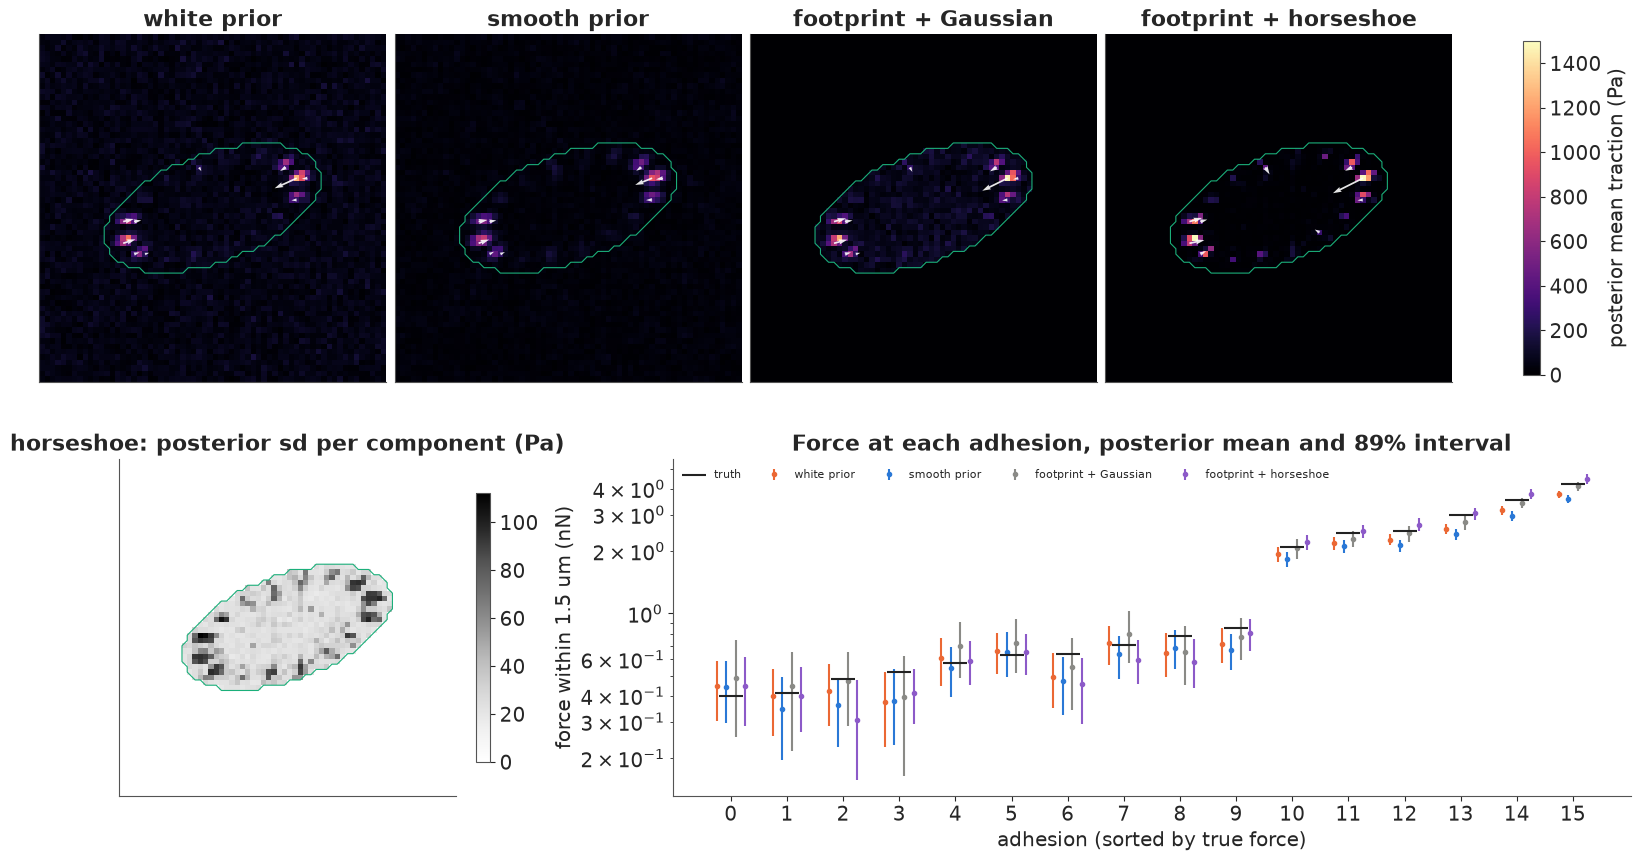

In [13]:
fig = plt.figure(figsize=(16, 8.6))
top, bot = fig.subfigures(2, 1, height_ratios=[1, 1])
axs = top.subplots(1, 4)
for ax, (nm, td) in zip(axs, METHODS.items()):
    im = show(ax, *td.mean(0), nm, 1500, mask=FOOT)
top.colorbar(im, ax=axs, shrink=0.8, label="posterior mean traction (Pa)")
axs = bot.subplots(1, 2, width_ratios=[1, 2.3])
im = axs[0].imshow(np.sqrt((ths[:, 0].var(0) + ths[:, 1].var(0)) / 2), origin="lower", cmap="Greys",
                   extent=ext)
axs[0].contour(XC, YC, FOOT, [0.5], colors=[AQUA], linewidths=0.8)
axs[0].set(title="horseshoe: posterior sd per component (Pa)", xticks=[], yticks=[])
bot.colorbar(im, ax=axs[0], shrink=0.8)
ax = axs[1]
order = np.argsort(F_true)
for j, ((nm, td), c) in enumerate(zip(METHODS.items(), [ORANGE, BLUE, GREY, PURPLE])):
    af = adhesion_forces(td[:, 0], td[:, 1])[:, order]
    lo, hi = np.quantile(af, [0.055, 0.945], axis=0)
    xpos = np.arange(len(order)) + (j - 1.5) * 0.17
    ax.errorbar(xpos, af.mean(0), yerr=[af.mean(0) - lo, hi - af.mean(0)], fmt="o", ms=3, color=c, label=nm)
ax.scatter(np.arange(len(order)), F_true[order], marker="_", s=300, color=INK, zorder=5, label="truth")
ax.set(yscale="log", xlabel="adhesion (sorted by true force)", ylabel="force within 1.5 um (nN)",
       xticks=np.arange(len(order)), title="Force at each adhesion, posterior mean and 89% interval")
ax.legend(fontsize=8, ncols=5, loc="upper left");

The horseshoe takes about a minute under nutpie: no divergences, every transition at tree depth 7,
$\hat R \le 1.03$, bulk ESS 96-220 for the local scales and the global parameters (enough for
means and 89% intervals, not for far tails; the noise sd is estimated almost exactly, 9.9 nm).

The four posterior means (top row) differ mostly **away from the adhesions**. The two stationary
priors leave a haze of noise over the whole field: 77% and 68% of their summed traction magnitude
lies outside the cell. The footprint removes all of it by construction. Inside the footprint the
Gaussian prior still spreads noise over every pixel, while the horseshoe shrinks the background
to almost exactly zero and keeps the adhesions sharp: it has the lowest error by far (RMSE 21 Pa
against 34-62), and the only total force anywhere near the truth (44 nN against 30; the others
75-107). It also overshoots the strongest peak (1,741 Pa against 1,450): large signals escape the
shrinkage and are concentrated into fewer pixels. The footprint Gaussian gets the peak right
(1,465 Pa) and pins the contractile moment (449 nN·µm, truth 450).

The horseshoe's posterior sd (bottom left) is what a stationary posterior could not give: it is
large at the adhesions and at a few candidate spots, and near zero elsewhere. The model knows
where it is unsure.

The weak adhesions (bottom right, left half of the plot) are the humbling part. All four methods
recover their forces to within about 0.1 nN on average; the priors differ in the background and at
the strong adhesions, not here. The 89% intervals of the footprint Gaussian cover all ten weak
adhesions (they are wide), the stationary priors 80-90%, the horseshoe only 7 of 10: shrinkage
pulls some weak adhesions towards zero with too much confidence. Its strain energy (3.6 fJ) and
contractile moment (445, interval 441-450) intervals also narrowly miss the truth. A sparsity
prior helps most of the map and hurts a little where the signal is as small as the prior's idea of
"nothing"; which matters more depends on the question.

## 7 · The pyTFM colony: which prior do the data support?

Now a real measurement. The pyTFM package (Bauer et al. 2021) ships example data: bead images
under small colonies of epithelial-type cells on a 49 kPa gel (Poisson ratio 0.49, 300 µm thick),
before and after the cells were removed, and the displacement fields its PIV step computed from
them (20 µm windows moved in 2.1 µm steps). We use one colony of 7 cells from the tutorial's
"knock-out" group (the tutorial says only that a critical cytoskeletal protein was knocked out),
the region pyTFM integrates forces over, and pyTFM's own tractions and reported numbers. The gel
is 300 µm thick, much more than the ~20-100 µm wavelengths that matter, so we keep the
infinite half-space (pyTFM uses a finite-thickness solution; the difference is confined to the
longest wavelengths).

In [14]:
data.describe("pytfm_colony_ko04")
raw = np.load(data.path("pytfm_colony_ko04"))
hR, E_R = float(raw["grid_um"]), float(raw["young_pa"])
uxR, uyR = raw["ux_um"].astype(float), raw["uy_um"].astype(float)
uxR, uyR = uxR - uxR.mean(), uyR - uyR.mean()               # drift = the k = 0 mode
m_force, m_col = raw["mask_force"], raw["mask_colony"]
txP, tyP = raw["tx_pytfm_pa"].astype(float), raw["ty_pytfm_pa"].astype(float)
nyR, nxR = uxR.shape
gR = kgrid(nyR, nxR, hR)
ULR, UTR = to_modes(uxR, uyR, gR)
XR, YR = np.meshgrid(np.arange(nxR) * hR, np.arange(nyR) * hR)
extR = [0, nxR * hR, 0, nyR * hR]
print(f"{nyR} x {nxR} grid, spacing {hR:.3f} um, field {nxR * hR:.0f} x {nyR * hR:.0f} um; "
      f"max |u| {np.hypot(uxR, uyR).max() * 1e3:.0f} nm; force region {m_force.sum()} px, colony {m_col.sum()} px")

pytfm_colony_ko04: NumPy .npz (open data.path(...) with np.load): substrate displacement field under a small cell colony (7 cells; 'a critical cytoskeletal protein knocked out', per the tutorial) measured by PIV (20 um windows, 18 um overlap) between bead images before and after the cells were removed. ux_um, uy_um: displacements in um on a 189 x 193 grid (spacing grid_um = 2.117 um; rows run along +y, i.e. the images were flipped so that y points up and the y components changed sign). tx_pytfm_pa, ty_pytfm_pa: pyTFM's own tractions (finite-thickness FTTC followed by a Gaussian filter). mask_force: region pyTFM sums forces over; mask_colony: the colony footprint. Gel substrate: young_pa = 49 kPa, poisson = 0.49, thickness_um = 300. pyTFM's reported contractility (2.13e-6 N) and strain energy (2.46e-13 J) are included.
  source: Bauer, Prechová, Fischer, Thievessen, Gregor & Fabry (2021), pyTFM: A tool for traction force and monolayer stress microscopy, PLoS Computational Biology 17:e10

  white prior, ML-II: log ML    255041; noise sd 1.86e-07 nm, scale 173 Pa


 smooth prior, ML-II: log ML    266988; noise sd 3.12 nm, scale 302 Pa, length scale 1.9 um


 matern prior, ML-II: log ML    269145; noise sd 3.35 nm, scale 1742 Pa, length scale 22.9 um, alpha 0.94


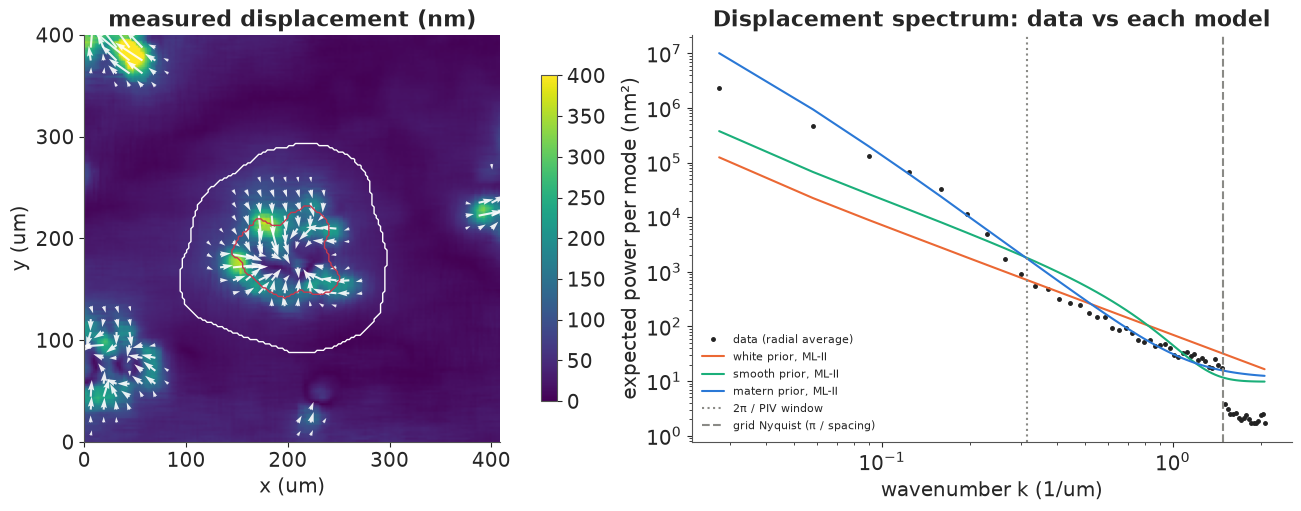

In [15]:
FITS_R = {}
for nm, p0 in (("white", [np.log(0.005), np.log(200)]),
               ("smooth", [np.log(0.005), np.log(300), np.log(2)]),
               ("matern", [np.log(0.005), np.log(300), np.log(10), 0.0])):
    FITS_R[nm] = max_log_ml(ULR, UTR, gR, E_R, nm, p0)
    lml_, p_ = FITS_R[nm]
    extra = "" if nm == "white" else f", length scale {np.exp(p_[2]):.1f} um"
    extra += f", alpha {np.exp(p_[3]):.2f}" if nm == "matern" else ""
    print(f"{nm:>7} prior, ML-II: log ML {lml_:9.0f}; noise sd {np.exp(p_[0]) * 1e3:.3g} nm, "
          f"scale {np.exp(p_[1]):.0f} Pa{extra}")

kb = np.linspace(0, gR["K"].max(), 60)
kbin = np.digitize(gR["K"], kb)
use = [b for b in range(1, len(kb)) if np.any((kbin == b) & gR["keep"])]
kmid = np.array([gR["K"][(kbin == b) & gR["keep"]].mean() for b in use])


def radial(P):
    return np.array([P[(kbin == b) & gR["keep"]].mean() for b in use])


gLR, gTR = green(gR, E_R)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
ax = axs[0]
im = show(ax, uxR * 1e3, uyR * 1e3, "measured displacement (nm)", 400, cmap="viridis", step=6,
          extent=extR, X=XR, Y=YR)
ax.contour(XR, YR, m_force, [0.5], colors="white", linewidths=1)
ax.contour(XR, YR, m_col, [0.5], colors=[RED], linewidths=1)
ax.set(xticks=[0, 100, 200, 300, 400], yticks=[0, 100, 200, 300, 400], xlabel="x (um)", ylabel="y (um)")
fig.colorbar(im, ax=ax, shrink=0.8)
ax = axs[1]
ax.loglog(kmid, radial((np.abs(ULR) ** 2 + np.abs(UTR) ** 2) / 2) * 1e6, ".", color=INK, ms=5,
          label="data (radial average)")
for (nm, (lml_, p_)), c in zip(FITS_R.items(), [ORANGE, AQUA, BLUE]):
    s2 = prior_s2(gR["K"], *p_[1:], *([None] * (4 - len(p_))))
    ax.loglog(kmid, radial((gLR**2 + gTR**2) / 2 * s2 + np.exp(2 * p_[0])) * 1e6, color=c,
              label=f"{nm} prior, ML-II")
ax.axvline(2 * np.pi / float(raw["piv_window_um"]), color=GREY, ls=":", label="2π / PIV window")
ax.axvline(np.pi / hR, color=GREY, ls="--", label="grid Nyquist (π / spacing)")
ax.set(xlabel="wavenumber k (1/um)", ylabel="expected power per mode (nm²)",
       title="Displacement spectrum: data vs each model")
ax.legend(fontsize=8);

The displacement field (left) shows the colony in the centre (its outline in red, pyTFM's force
region in white) pulling the gel inwards by a few hundred nm, and other cells at the edges of the
field of view, some cut by the image border.

The spectrum (right) is the most useful plot in this section. For each model it compares the power
the marginal likelihood *expects* in each Fourier mode, $(g_L^2 + g_T^2)\, s^2(k)/2 + \sigma^2$, with
what the data have, radially averaged: a posterior predictive check that costs nothing.

- The **white prior** (orange) fails in a way that the fit statistics alone would hide. Its
  predicted displacement power falls only as $1/k^2$; the data fall much faster, because PIV has
  already averaged the displacements over 20 µm windows. ML-II then explains even the finest
  modes as signal and sets the noise to zero (printed: $2 \times 10^{-7}$ nm), i.e. $\lambda \to 0$:
  no regularisation at all.
- The **squared-exponential** prior (green) finds a length scale of 1.9 µm and 3.1 nm of noise,
  but it cannot bend enough: it under-predicts the long waves tenfold.
- A **Matérn-like** spectrum $s^2(k) = s_0^2 (1 + k^2\ell^2)^{-\alpha}$ (blue) follows the data over
  two decades: $\ell = 23$ µm, $\alpha = 0.94$, 3.4 nm of noise. Its
  log marginal likelihood is 2,157 higher than the squared exponential's and 14,104 higher than
  the white prior's.

Two misfits remain. The lowest two wavenumbers (wavelengths above ~100 µm, a quarter of the field or more)
carry less power than predicted: the model assumes a stationary field, and this field of view
happens to hold a few colonies. And beyond the grid's Nyquist wavenumber (only the "corner" modes
along the diagonals exist there) the data have about 2 nm² of power where the model expects 12:
the PIV noise is not white. Neighbouring vectors come from windows that overlap by 90% and share
most of their beads, so their errors are strongly correlated. The posterior widths below treat the
noise as white, so they are too narrow.

## 8 · Forces with credible intervals, against pyTFM

In [16]:
t0 = time.time()
id_R = fit_hyper(ULR, UTR, gR, E_R, "matern", sig0=0.003, s0=1000.0, ell0=20.0)
print(f"Matern prior on the colony: {time.time() - t0:.0f} s")
report(id_R, "Matern prior, real colony")


def contractility(fx, fy, mask, X, Y, h, centre):
    """Forces projected on the direction to the force epicentre, summed (pyTFM's definition), in uN."""
    dx, dy = centre[0] - X, centre[1] - Y
    proj = (fx * dx + fy * dy) / (np.hypot(dx, dy) + 1e-9) * mask
    return np.sum(proj.reshape(*fx.shape[:-2], -1), axis=-1) * h**2 * 1e-6


def epicentre(fx, fy, mask, X, Y, h):
    """The point towards which the projected forces are largest."""
    c0 = [X[mask].mean(), Y[mask].mean()]
    return minimize(lambda c: -contractility(fx, fy, mask, X, Y, h, c), c0, method="Nelder-Mead").x


def colony_numbers(fx, fy, centre):
    return (strain_energy(fx, fy, uxR, uyR, m_force, hR), contractility(fx, fy, m_force, XR, YR, hR, centre))


NDRAW_R, CHUNK = 200, 25
tR_sum, tR_sq = np.zeros((2, nyR, nxR)), np.zeros((2, nyR, nxR))
UR_d, CR_d = np.empty(NDRAW_R), np.empty(NDRAW_R)
for j0 in range(0, NDRAW_R, CHUNK):                           # in chunks: each draw is 2 x 189 x 193
    td = draw_tractions(ULR, UTR, gR, E_R, id_R, CHUNK, RANDOM_SEED + 100 + j0)
    if j0 == 0:
        centre_R = epicentre(*td.mean(0), m_force, XR, YR, hR)
    tR_sum += td.sum(0)
    tR_sq += (td**2).sum(0)
    UR_d[j0:j0 + CHUNK], CR_d[j0:j0 + CHUNK] = colony_numbers(td[:, 0], td[:, 1], centre_R)
    del td
tR_mean = tR_sum / NDRAW_R
tR_sd = np.sqrt(np.maximum(tR_sq / NDRAW_R - tR_mean**2, 0))
E_R_draws = E_R * np.exp(0.15 * np.random.default_rng(RANDOM_SEED + 7).standard_normal(NDRAW_R))
ROWS_R = {"pyTFM tractions": colony_numbers(txP, tyP, epicentre(txP, tyP, m_force, XR, YR, hR))}
for nm in ("white", "smooth", "matern"):
    lml_, p_ = FITS_R[nm]
    s2 = prior_s2(gR["K"], *p_[1:], *([None] * (4 - len(p_))))
    tt_ = reconstruct(ULR, UTR, gR, E_R, s2, np.exp(2 * p_[0]))
    ROWS_R[f"{nm} prior (ML-II mean)"] = colony_numbers(*tt_, epicentre(*tt_, m_force, XR, YR, hR))
print(f"pyTFM reports: strain energy {float(raw['pytfm_strain_energy_j']) * 1e15:.0f} fJ, "
      f"contractility {float(raw['pytfm_contractility_n']) * 1e6:.2f} uN")
for nm, (u_, c_) in ROWS_R.items():
    print(f"{nm:>26}: strain energy {u_:6.1f} fJ, contractility {c_:5.3f} uN")
for lab, d_ in (("strain energy (fJ)", UR_d), ("contractility (uN)", CR_d)):
    lo, hi = np.quantile(d_, [0.055, 0.945])
    loE, hiE = np.quantile(d_ * E_R_draws / E_R, [0.055, 0.945])
    print(f"Matern posterior, {lab}: {d_.mean():.4g}, 89% [{lo:.4g}, {hi:.4g}] with E known; "
          f"[{loE:.3g}, {hiE:.3g}] with E +- 15%")

Matern prior on the colony: 108 s
--- Matern prior, real colony: 0 divergences, 400 tuning steps (nutpie)
             mean      sd  eti94_lb  eti94_ub   ess_bulk   r_hat
log_sig   -5.6978  0.0078   -5.7122   -5.6830  1890.7767  1.0016
log_s      7.4823  0.1211    7.2788    7.7306   537.5057  1.0065
log_ell    3.1526  0.1453    2.9067    3.4516   556.5913  1.0061
log_alpha -0.0650  0.0114   -0.0863   -0.0441   924.7425  1.0035


pyTFM reports: strain energy 246 fJ, contractility 2.13 uN
           pyTFM tractions: strain energy  252.2 fJ, contractility 2.170 uN
  white prior (ML-II mean): strain energy  280.4 fJ, contractility 2.177 uN
 smooth prior (ML-II mean): strain energy  272.2 fJ, contractility 2.173 uN
 matern prior (ML-II mean): strain energy  271.3 fJ, contractility 2.173 uN
Matern posterior, strain energy (fJ): 271.2, 89% [271, 271.5] with E known; [213, 337] with E +- 15%
Matern posterior, contractility (uN): 2.173, 89% [2.167, 2.18] with E known; [1.71, 2.7] with E +- 15%


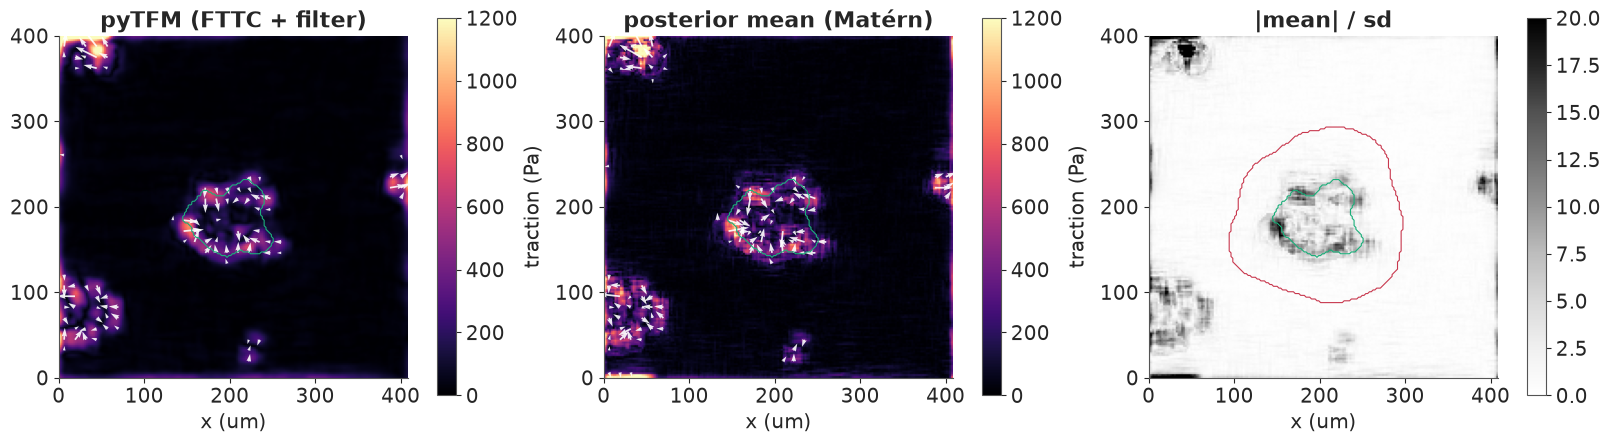

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (fx, fy), title in zip(axs[:2], [(txP, tyP), tR_mean],
                               ["pyTFM (FTTC + filter)", "posterior mean (Matérn)"]):
    im = show(ax, fx, fy, title, 1200, step=6, extent=extR, X=XR, Y=YR, mask=m_col)
    ax.set(xticks=[0, 100, 200, 300, 400], yticks=[0, 100, 200, 300, 400], xlabel="x (um)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="traction (Pa)")
ax = axs[2]
im = ax.imshow(np.hypot(*tR_mean) / np.sqrt((tR_sd[0] ** 2 + tR_sd[1] ** 2) / 2), origin="lower",
               cmap="Greys", vmin=0, vmax=20, extent=extR)
ax.contour(XR, YR, m_col, [0.5], colors=[AQUA], linewidths=0.8)
ax.contour(XR, YR, m_force, [0.5], colors=[RED], linewidths=0.8)
ax.set(title="|mean| / sd", xlabel="x (um)")
fig.colorbar(im, ax=ax, shrink=0.8);

The Matérn fit takes one and a half to two minutes (four hyperparameters, 72,000 modes per
gradient evaluation): no divergences, $\hat R \le 1.007$, bulk ESS about 500 for the correlated pair $(s_0, \ell)$
and more for the rest. The posterior mean traction (middle) looks much like pyTFM's filtered FTTC
(left): the colony pulls at its periphery, with the strongest tractions (~1 kPa) at its left, top and
lower right edges, and the cells at the image borders show up too. Both maps have artefacts along
the image edges, where cells are cut off and the periodic FFT wraps one border onto the other; they
lie outside the force region. The right panel shows the posterior mean in units of posterior sd:
the colony's tractions are many sds from zero (the scale saturates at 20).

The numbers (printout):

| | strain energy (fJ) | contractility (µN) |
|---|---|---|
| pyTFM, as reported | 246 | 2.13 |
| pyTFM's tractions, our formulas | 252 | 2.17 |
| white / squared-exp. / Matérn prior (ML-II mean) | 280 / 272 / 271 | 2.177 / 2.173 / 2.173 |
| Matérn posterior, $E$ known, 89% | 271.0 - 271.6 | 2.167 - 2.180 |
| Matérn posterior, $E$ ± 15%, 89% | 213 - 338 | 1.71 - 2.70 |

(pyTFM subtracts a background level from its energy map, hence 246 rather than 252.) The
**contractility** - forces projected towards the colony's force epicentre, a linear functional like
the contractile moment - agrees across all priors and with pyTFM to within 2%. The **strain
energy** depends on the prior: 7-11% higher than from pyTFM's Gaussian-filtered field, consistent
with the simulation, where smoothing the tractions lowered the energy. Both spreads, and the
measurement's posterior width (under 1%), are small next to what a 15% uncertainty about the gel's
stiffness does (-21% to +25%; the example data give no uncertainty for the 49 kPa, so the 15% is our
assumption). The posterior width with $E$ known is also optimistic because the PIV noise is not
white. In a real study, the honest error bar on this colony's strain energy would be dominated by
the gel, then by the choice of regulariser, and last by the displacement noise.

## Summary

- **TFM is a linear inverse problem, diagonal in Fourier space.** The Boussinesq Green's function of
  an elastic half-space splits into longitudinal and transverse modes, $g \propto 1/(Ek)$; inverting
  multiplies noise by $k$ (sections 1-2).
- **Tikhonov regularisation is a white Gaussian prior**, and $\lambda = \sigma^2/s^2$. The marginal
  likelihood is closed form and chooses $\lambda$ and the noise level from the data. On this problem
  the L-curve has no corner (its maximum-curvature rule depends on the scan range); the discrepancy
  principle is excellent if you know $\sigma$ (section 3).
- **Hyperparameters in PyMC, fields in NumPy.** NUTS samples the few hyperparameters with the field
  integrated out; exact joint draws of the field follow by FFT. With thousands of modes the
  hyperparameter posterior is so narrow that full Bayes and ML-II agree (sections 4, 8).
- **Better priors beat better tuning**: a GP smoothness spectrum tuned by the data matched the
  oracle Tikhonov solution; on real PIV data only a Matérn-like spectrum fitted, and the white prior
  collapsed to no regularisation at all. The displacement power spectrum is a free predictive check
  (sections 4, 7).
- **Credible intervals are conditional on the prior.** Linear summaries (contractile moment,
  contractility) are robust; strain energy moves with the prior by more than its posterior width;
  total $\int|\mathbf t|$ is dominated by noise. A stationary posterior's sd map is flat and says
  nothing about where it is wrong (sections 4, 6, 8).
- **The gel's stiffness dominates**: tractions scale with $E$, the displacements say nothing about
  it, and a 15% AFM uncertainty accounts for 97-100% of the posterior variance of every summary
  (sections 5, 8).
- **Priors that know biology**: restricting tractions to the cell footprint removes the background;
  a regularised horseshoe keeps adhesions sharp, gives the best map and a sd map that knows where
  it is unsure, but can be over-confident about the weakest adhesions (section 6).

## Try it yourself

1. **Compare cells.** The pyTFM example data (github.com/fabrylab/example_data_for_pyTFM,
   `clickpoints_tutorial/*_analyzed/`) hold two wild-type and two knock-out colonies. Fit each with
   the Matérn prior and compute the posterior of the knock-out / wild-type ratio of contractility and
   of strain energy, with one shared uncertain $E$. How much of the 15% stiffness uncertainty cancels,
   and does the difference survive the remaining uncertainty and the prior's effect on strain energy?
2. **Model the PIV noise.** Section 7 showed that the noise is smoother than white. Replace
   $\sigma^2$ by a noise spectrum - for instance $\sigma_1^2 W(k)^2 + \sigma_0^2$, where $W$ is the
   transfer function of a 20 µm box window - fit it by marginal likelihood, and check it on the
   spectrum plot. How much wider do the posterior intervals of the colony's strain energy get?
3. **A sparse colony.** Apply the footprint and horseshoe priors of section 6 to the real colony on
   a coarser grid (every second PIV vector, so the footprint has a few hundred pixels). You will need
   a footprint for the other cells in the field of view too - or crop them away, and think about
   what the periodic FFT does at the new borders. Do the strain energy and contractility move?